## Storm Identification and Classification Using POT and K-Means
ECAN Spectral Wave Buoy Data

## Objective and Overview
This analysis aims to:

Clean and preprocess ECAN wave buoy data

Identify storm events using a Peak Over Threshold (POT) approach:

Significant wave height Hs ≥ 2.5 m

Minimum storm duration: 24 hours

Storm separation: 24 hours

Extract storm-level characteristics

Normalize variables and handle directional data using circular statistics

Cluster storms using K-means

Determine optimal number of clusters

Validate clustering results

Store outputs and generate diagnostic plots

## Load Required Libraries
We load libraries for data handling, visualization, clustering, and circular statistics.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from pandas import Timedelta
from datetime import timedelta

## Load Raw Data

In [49]:
file_path = r"C:\Users\User\Documents\UC\DATA601\Erosion\erosion resources\Wave Buoy analysis\ECAN_waves_Nov2025_Complete QC spectral wave buoy data(Wave Buoy data).csv"

df = pd.read_csv(file_path)
df.head()

,Date (UTC),Time (UTC),Julian Date,Peak Period Tpeak (s),Peak Direction Dp (deg),Direction Spread (Deg),Mean period Tm01 (s),Mean period Tm02 (s),Sig wave height Hm0 (m),Spectral peakedness Qp
0,6/02/1999,12:23:00,36197.52,11.11,132.28,48.90,5.63,NaN,1.05,1.39
1,6/02/1999,20:23:00,36197.85,5.56,64.78,41.74,5.41,NaN,1.04,1.41
2,6/02/1999,23:23:00,36197.97,11.76,111.19,56.29,5.88,NaN,0.96,1.39
3,7/02/1999,6:24:00,36198.27,7.14,66.19,28.65,6.45,NaN,1.62,1.80
4,7/02/1999,8:24:00,36198.35,7.69,64.78,33.35,6.45,NaN,1.74,1.84


## Initial Data Cleaning and Preprocessing
Steps:

Combine Date and Time into a single datetime variable

Sort chronologically

Rename variables for clarity

Handle missing values conservatively

In [50]:
# Rename columns for consistency
df.columns = [
    "date", "time", "julian_date", "tpeak", "dp",
    "dir_spread", "tm01", "tm02", "hs", "qp"
]

# Create datetime column
df["datetime"] = pd.to_datetime(
    df["date"].astype(str) + " " + df["time"].astype(str),
    dayfirst=True,
    errors="coerce"
)

# Sort by time
df = df.sort_values("datetime").reset_index(drop=True)

# Remove rows with missing critical values
df = df.dropna(subset=["datetime", "hs", "dp"])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 363949 entries, 0 to 363948
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   date         363949 non-null  object        
 1   time         363949 non-null  object        
 2   julian_date  363949 non-null  float64       
 3   tpeak        363949 non-null  float64       
 4   dp           363949 non-null  float64       
 5   dir_spread   363949 non-null  float64       
 6   tm01         298980 non-null  float64       
 7   tm02         64969 non-null   float64       
 8   hs           363949 non-null  float64       
 9   qp           363949 non-null  float64       
 10  datetime     363949 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(8), object(2)
memory usage: 30.5+ MB


In [51]:
# Print current columns first to diagnose (run this before renaming)
print("Current columns:", df.columns.tolist())
print("Number of columns:", len(df.columns))

Current columns: ['date', 'time', 'julian_date', 'tpeak', 'dp', 'dir_spread', 'tm01', 'tm02', 'hs', 'qp', 'datetime']
Number of columns: 11


In [52]:
# Drop the extra datetime column (keep only the 10 core columns)
df = df[['date', 'time', 'julian_date', 'tpeak', 'dp', 
         'dir_spread', 'tm01', 'tm02', 'hs', 'qp']]

# NOW create fresh datetime column
df["datetime"] = pd.to_datetime(
    df["date"].astype(str) + " " + df["time"].astype(str),
    dayfirst=True,
    errors="coerce"
)

# Sort, clean, set index
df = df.sort_values("datetime").reset_index(drop=True)
df = df.dropna(subset=["datetime", "hs", "dp"])
df.set_index("datetime", inplace=True)

df.info()
print(df.head())


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 363949 entries, 1999-02-06 12:23:00 to 2025-09-30 23:32:55
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   date         363949 non-null  object 
 1   time         363949 non-null  object 
 2   julian_date  363949 non-null  float64
 3   tpeak        363949 non-null  float64
 4   dp           363949 non-null  float64
 5   dir_spread   363949 non-null  float64
 6   tm01         298980 non-null  float64
 7   tm02         64969 non-null   float64
 8   hs           363949 non-null  float64
 9   qp           363949 non-null  float64
dtypes: float64(8), object(2)
memory usage: 30.5+ MB
                          date      time  julian_date  tpeak      dp  \
datetime                                                               
1999-02-06 12:23:00  6/02/1999  12:23:00     36197.52  11.11  132.28   
1999-02-06 20:23:00  6/02/1999  20:23:00     36197.85   5.56   64.78  

## Quality Control and Physical Constraints
Wave data must obey physical limits.

Peak Over Threshold (POT) Storm Identification
Storm Definition:

Hs ≥ 2.5 m

Events separated by ≥ 24 hours

Minimum storm duration ≥ 24 hours

In [53]:
HS_THRESHOLD = 2.5
MIN_DURATION = Timedelta(hours=24) 
SEPARATION = Timedelta(hours=24)

# Identify exceedances
df["exceed"] = df["hs"] >= HS_THRESHOLD

## Extract Individual Storm Events
Storms are grouped using temporal continuity and separation rules.

In [54]:
storms = []
current_storm = []

for i, row in df.iterrows():
    if row["exceed"]:
        if not current_storm:
            current_storm.append(row)
        else:
            if row.name - current_storm[-1].name <= SEPARATION:
                current_storm.append(row)
            else:
                storms.append(pd.DataFrame(current_storm))
                current_storm = [row]
    else:
        if current_storm:
            storms.append(pd.DataFrame(current_storm))
            current_storm = []

if current_storm:
    storms.append(pd.DataFrame(current_storm))

## Filter Storms by Minimum Duration

In [55]:
# DEBUG - check structure properly
print("Storms type:", type(storms))
print("First storm type:", type(storms[0]) if storms else "No storms")
print("First storm shape:", storms[0].shape if storms else "No storms")

# FIXED validation for DataFrame storms
valid_storms = []
for storm_df in storms:
    duration = storm_df.index.max() - storm_df.index.min()  # Use INDEX directly
    if duration >= MIN_DURATION:
        valid_storms.append(storm_df)

print(f"Valid storms (≥24hr): {len(valid_storms)}")


Storms type: <class 'list'>
First storm type: <class 'pandas.core.frame.DataFrame'>
First storm shape: (2, 11)
Valid storms (≥24hr): 585


## Derive Storm-Level Features
Each storm is summarized into physically meaningful descriptors.

In [56]:
storm_features = []
for storm in valid_storms:
    duration = (storm.index.max() - storm.index.min()).total_seconds() / 3600  # Use .index
    storm_features.append({
        "duration_hours": duration,
        "max_hs": storm["hs"].max(),
        "mean_hs": storm["hs"].mean(),
        "mean_tpeak": storm["tpeak"].mean(),
        "mean_dir": storm["dp"].mean(),
        "mean_qp": storm["qp"].mean()
    })

storm_df = pd.DataFrame(storm_features)
print(storm_df.head())
print(f"Total storms: {len(storm_df)}")


   duration_hours  max_hs   mean_hs  mean_tpeak    mean_dir   mean_qp
0       33.000000    3.48  2.861111    9.657778  199.156667  1.761111
1       50.000000    5.44  4.015625   10.236875  175.698750  2.170000
2       24.000000    3.67  3.323333   13.095556  188.062222  1.818889
3       32.983333    3.45  2.973333    9.815833  167.320833  2.065000
4       77.983333    3.19  2.874000   10.872500  144.795500  1.930500
Total storms: 585


## Circular Statistics for Wave Direction
Directional data is circular, not linear.

In [57]:
# Compute circular mean direction per storm
storm_df["mean_dir"] = [
    (
        np.degrees(
            np.arctan2(
                np.mean(np.sin(np.deg2rad(storm["dp"].values))),
                np.mean(np.cos(np.deg2rad(storm["dp"].values)))
            )
        )
        + 360
    ) % 360
    for storm in valid_storms
]

# Encode direction for clustering
storm_df["dir_sin"] = np.sin(np.deg2rad(storm_df["mean_dir"]))
storm_df["dir_cos"] = np.cos(np.deg2rad(storm_df["mean_dir"]))

## Prepare Data for Clustering
Normalization is essential for K-means.

In [58]:
features = storm_df[
    ["duration_hours", "max_hs", "mean_hs",
     "mean_tpeak", "mean_qp", "dir_sin", "dir_cos"]
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

## Determine Optimal Number of Clusters (k)
We use:

Elbow method

Silhouette score

In [59]:
k_range = range(2, 8)
inertia = []
silhouette = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    inertia.append(model.inertia_)
    silhouette.append(silhouette_score(X_scaled, labels))

## Diagnostic Plots for k Selection

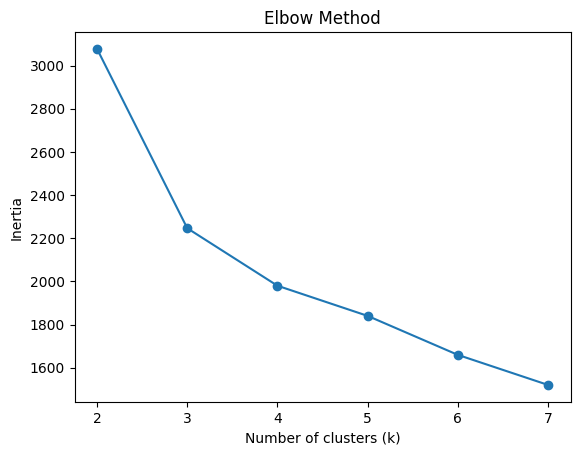

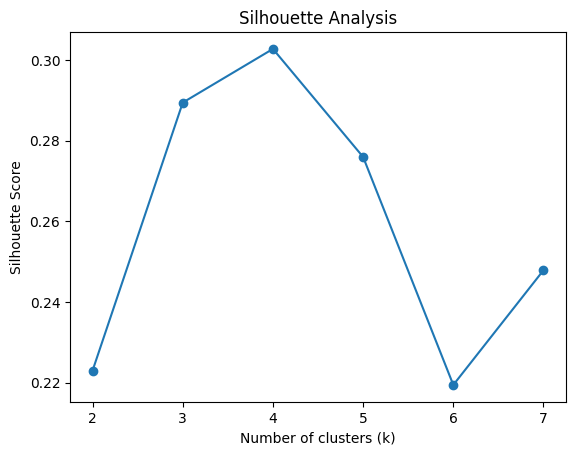

In [60]:
plt.figure()
plt.plot(k_range, inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

plt.figure()
plt.plot(k_range, silhouette, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

## Optimal k is selected where:
Inertia begins to flatten

Silhouette score is maximized

In [61]:
## Final K-Means Clustering

In [62]:
optimal_k = 3 

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
storm_df["cluster"] = kmeans.fit_predict(X_scaled)

## Cluster Validation and Interpretation

## Interpret clusters in terms of:
Storm intensity

Duration

Dominant wave direction

Spectral peakedness

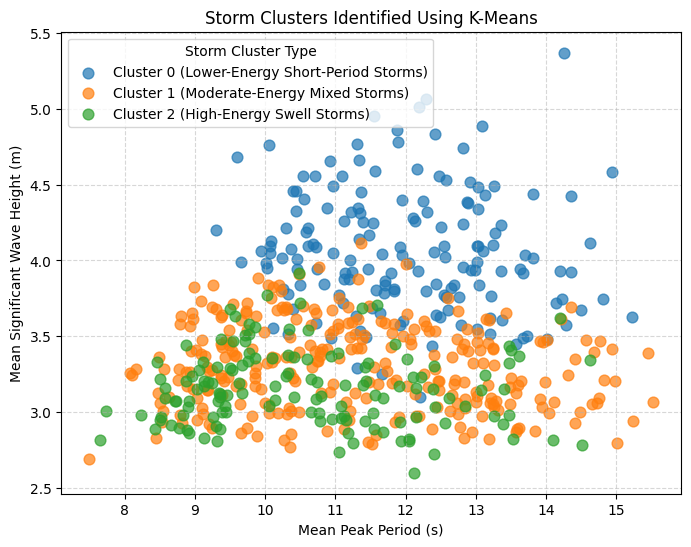

In [63]:
labels = {
    0: "Lower-Energy Short-Period Storms",
    1: "Moderate-Energy Mixed Storms",
    2: "High-Energy Swell Storms"
}

plt.figure(figsize=(8, 6))

for c in sorted(storm_df["cluster"].unique()):
    subset = storm_df[storm_df["cluster"] == c]
    plt.scatter(
        subset["mean_tpeak"],
        subset["mean_hs"],
        label=f"Cluster {c} ({labels[c]})",
        alpha=0.7,
        s=60
    )

plt.xlabel("Mean Peak Period (s)")
plt.ylabel("Mean Significant Wave Height (m)")
plt.title("Storm Clusters Identified Using K-Means")
plt.legend(title="Storm Cluster Type")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


## Clustered Storm Types: Duration vs Intensity
What this plot shows

X-axis → Storm duration (hours) → persistence

Y-axis → Mean significant wave height (m) → intensity

Colour → Storm cluster

This helps distinguish long-lasting vs short but intense storms.

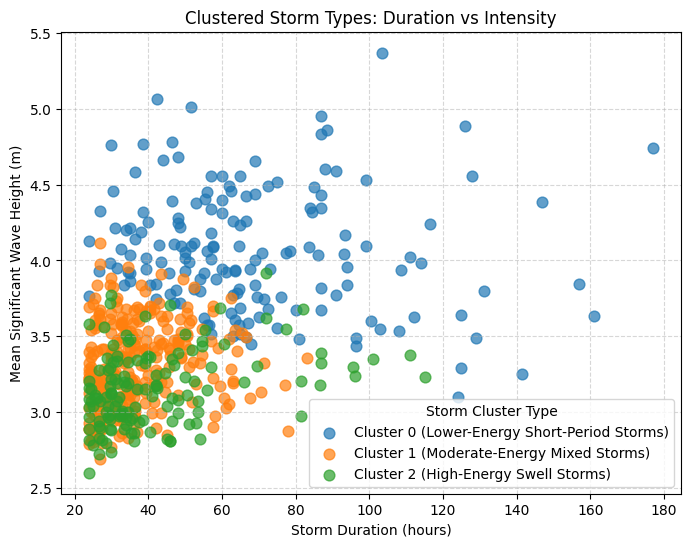

In [64]:
labels = {
    0: "Lower-Energy Short-Period Storms",
    1: "Moderate-Energy Mixed Storms",
    2: "High-Energy Swell Storms"
}

plt.figure(figsize=(8, 6))

for c in sorted(storm_df["cluster"].unique()):
    subset = storm_df[storm_df["cluster"] == c]
    plt.scatter(
        subset["duration_hours"],
        subset["mean_hs"],
        label=f"Cluster {c} ({labels[c]})",
        alpha=0.7,
        s=60
    )

plt.xlabel("Storm Duration (hours)")
plt.ylabel("Mean Significant Wave Height (m)")
plt.title("Clustered Storm Types: Duration vs Intensity")
plt.legend(title="Storm Cluster Type")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## Clustered Storm Types: Direction vs Intensity
What this plot shows

X-axis → Mean wave direction (degrees)

Y-axis → Mean significant wave height (m)

Colour → Storm cluster

This highlights directional exposure and whether extreme storms come from specific approach angles.

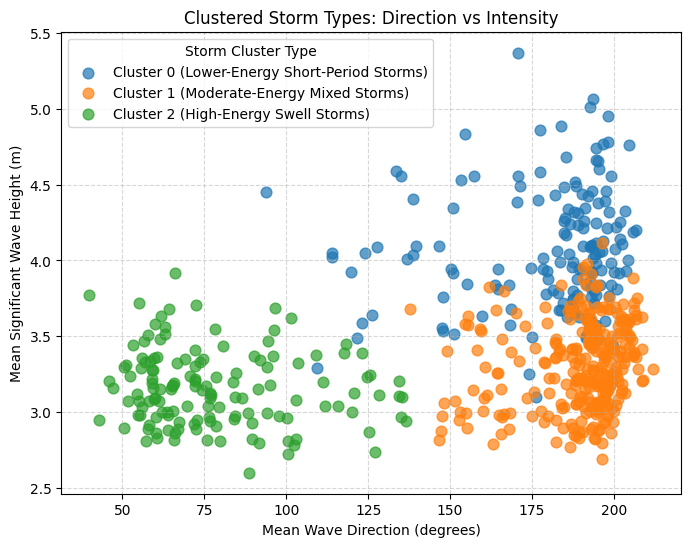

In [65]:
plt.figure(figsize=(8, 6))

for c in sorted(storm_df["cluster"].unique()):
    subset = storm_df[storm_df["cluster"] == c]
    plt.scatter(
        subset["mean_dir"],
        subset["mean_hs"],
        label=f"Cluster {c} ({labels[c]})",
        alpha=0.7,
        s=60
    )

plt.xlabel("Mean Wave Direction (degrees)")
plt.ylabel("Mean Significant Wave Height (m)")
plt.title("Clustered Storm Types: Direction vs Intensity")
plt.legend(title="Storm Cluster Type")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [66]:
output_path = r"C:\Users\User\Documents\UC\DATA601\Erosion\erosion resources\Wave Buoy analysis\storm_clusters.csv"
storm_df.to_csv(output_path, index=False)